# Session 39: Hyperparameter Tuning I

## Section 8 GitHub Deliverable

This notebook tunes a `DecisionTreeRegressor` using five-fold cross-validated grid search.

The early-warning design excludes `G1` and `G2`. It compares a default tree with the tuned tree, reports every tested parameter combination, evaluates the selected model on an untouched test set, and provides an interpretation and recommendation.

In [1]:
import json
import tempfile
import time
import warnings
import zipfile
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

SESSION_NUMBER = 39
RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()

print("Session:", SESSION_NUMBER)
print("Project root:", PROJECT_ROOT)
print("scikit-learn version:", sklearn.__version__)

Session: 39
Project root: C:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\student-performance-prediction-ml
scikit-learn version: 1.9.0


## 1. Load the public student-performance dataset

The notebook first checks the project `data` folder. If the dataset is not present, it downloads the official UCI Student Performance archive into a temporary Windows folder. No manual upload is required.

In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"

data_candidates = []
project_data_dir = PROJECT_ROOT / "data"

if project_data_dir.exists():
    data_candidates.extend(project_data_dir.rglob("student-mat.csv"))

data_candidates.extend(PROJECT_ROOT.glob("student-mat.csv"))

if data_candidates:
    DATA_PATH = sorted(data_candidates)[0]
    data_source = "existing project file"
else:
    temporary_data_dir = Path(tempfile.gettempdir()) / "gssrp_session39_data"
    temporary_data_dir.mkdir(parents=True, exist_ok=True)
    zip_path = temporary_data_dir / "student_performance.zip"
    extract_dir = temporary_data_dir / "extracted"

    if not zip_path.exists():
        print("Downloading the UCI Student Performance dataset...")
        urlretrieve(DATA_URL, zip_path)

    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zip_file:
        zip_file.extractall(extract_dir)

    extracted_candidates = list(extract_dir.rglob("student-mat.csv"))
    if not extracted_candidates:
        raise FileNotFoundError("student-mat.csv was not found after extraction.")

    DATA_PATH = extracted_candidates[0]
    data_source = "UCI download in the temporary folder"

print("Dataset source:", data_source)
print("Dataset path:", DATA_PATH)

Dataset source: existing project file
Dataset path: C:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\student-performance-prediction-ml\data\student-mat.csv


In [3]:
df = pd.read_csv(DATA_PATH, sep=";")

TARGET_COLUMN = "G3"
EXCLUDED_COLUMNS = ["G1", "G2", TARGET_COLUMN]
required_columns = {"G1", "G2", "G3"}

if not required_columns.issubset(df.columns):
    raise ValueError(
        "Required columns are missing: "
        + str(sorted(required_columns.difference(df.columns)))
    )

X = df.drop(columns=EXCLUDED_COLUMNS).copy()
y = df[TARGET_COLUMN].copy()

assert "G1" not in X.columns
assert "G2" not in X.columns
assert "G3" not in X.columns
assert len(X) == len(y)

print("Dataset shape:", df.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("G1 included:", "G1" in X.columns)
print("G2 included:", "G2" in X.columns)
print("G3 included as a feature:", "G3" in X.columns)
display(df.head())

Dataset shape: (395, 33)
Feature matrix shape: (395, 30)
Target shape: (395,)
G1 included: False
G2 included: False
G3 included as a feature: False


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Create the leakage-safe preprocessing and train/test split

Numeric features receive median imputation. Categorical features receive most-frequent imputation and one-hot encoding. Preprocessing remains inside each model pipeline so it is fitted only on training data.

In [4]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)


def make_preprocessor():
    numeric_transformer = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="median"))]
    )

    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features),
        ],
        remainder="drop",
    )


print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("PASS: Feature and target indices are aligned.")

Numeric features: 13
Categorical features: 17
Training rows: 316
Test rows: 79
PASS: Feature and target indices are aligned.


## 3. Train the default decision-tree baseline

The default tree provides the reference needed to determine whether cross-validated tuning improves generalization.

In [5]:
def regression_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Test_MAE": round(float(mean_absolute_error(y_true, y_pred)), 4),
        "Test_RMSE": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "Test_R2": round(float(r2_score(y_true, y_pred)), 4),
    }


default_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor()),
        ("model", DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ]
)

default_tree_pipeline.fit(X_train, y_train)

default_train_predictions = default_tree_pipeline.predict(X_train)
default_test_predictions = default_tree_pipeline.predict(X_test)
default_train_r2 = r2_score(y_train, default_train_predictions)

default_results = regression_metrics(
    "Default Decision Tree",
    y_test,
    default_test_predictions,
)

default_tree = default_tree_pipeline.named_steps["model"]
default_results.update(
    {
        "Train_R2": round(float(default_train_r2), 4),
        "Tree_Depth": int(default_tree.get_depth()),
        "Leaf_Count": int(default_tree.get_n_leaves()),
        "Node_Count": int(default_tree.tree_.node_count),
    }
)

print("Default decision-tree results:")
display(pd.DataFrame([default_results]))

Default decision-tree results:


,Model,Test_MAE,Test_RMSE,Test_R2,Train_R2,Tree_Depth,Leaf_Count,Node_Count
0,Default Decision Tree,3.5696,4.776,-0.1124,1.0,21,223,445


## 4. Tune `max_depth` and `min_samples_split`

The grid contains four `max_depth` values and three `min_samples_split` values: 12 combinations and 60 total fits under five-fold cross-validation.

In [6]:
parameter_grid = {
    "model__max_depth": [3, 5, 7, None],
    "model__min_samples_split": [2, 5, 10],
}

number_of_combinations = (
    len(parameter_grid["model__max_depth"])
    * len(parameter_grid["model__min_samples_split"])
)
number_of_fits = number_of_combinations * 5

assert number_of_combinations == 12
assert number_of_fits == 60

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor()),
        ("model", DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ]
)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=parameter_grid,
    scoring="r2",
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
    verbose=1,
)

start_time = time.time()
grid_search.fit(X_train, y_train)
elapsed_seconds = time.time() - start_time

best_parameters = {
    key.replace("model__", ""): value
    for key, value in grid_search.best_params_.items()
}

print("Parameter combinations:", number_of_combinations)
print("Cross-validation folds:", 5)
print("Total model fits:", number_of_fits)
print("Elapsed seconds:", round(elapsed_seconds, 2))
print("Best parameters:", best_parameters)
print("Best cross-validated R2:", round(float(grid_search.best_score_), 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Parameter combinations: 12
Cross-validation folds: 5
Total model fits: 60
Elapsed seconds: 9.73
Best parameters: {'max_depth': 3, 'min_samples_split': 2}
Best cross-validated R2: 0.0918


In [7]:
cv_results = pd.DataFrame(grid_search.cv_results_)

grid_results_table = pd.DataFrame(
    {
        "Rank": cv_results["rank_test_score"].astype(int),
        "Max_Depth": cv_results["param_model__max_depth"].astype(str),
        "Min_Samples_Split": cv_results["param_model__min_samples_split"].astype(int),
        "Mean_Train_R2": cv_results["mean_train_score"],
        "Mean_CV_R2": cv_results["mean_test_score"],
        "CV_R2_Std": cv_results["std_test_score"],
        "Mean_Fit_Time_Seconds": cv_results["mean_fit_time"],
    }
)

grid_results_table = grid_results_table.sort_values(
    by=["Rank", "Mean_CV_R2"],
    ascending=[True, False],
).reset_index(drop=True)

for column in [
    "Mean_Train_R2",
    "Mean_CV_R2",
    "CV_R2_Std",
    "Mean_Fit_Time_Seconds",
]:
    grid_results_table[column] = grid_results_table[column].round(4)

print("Complete grid-search results:")
display(grid_results_table)

Complete grid-search results:


,Rank,Max_Depth,Min_Samples_Split,Mean_Train_R2,Mean_CV_R2,CV_R2_Std,Mean_Fit_Time_Seconds
0,1,3,2,0.3647,0.0918,0.1660,0.1313
1,1,3,5,0.3647,0.0918,0.1660,0.0998
2,1,3,10,0.3647,0.0918,0.1660,0.0531
3,4,5,10,0.5543,-0.0757,0.2289,0.0541
4,5,5,2,0.5987,-0.0997,0.2448,0.0560
5,6,5,5,0.5852,-0.1325,0.2113,0.0538
6,7,7,10,0.6809,-0.2006,0.3246,0.0509
7,8,7,5,0.7430,-0.2771,0.2633,0.0541
8,9,7,2,0.7865,-0.3221,0.3499,0.0519
9,10,NaN,10,0.8003,-0.3376,0.3088,0.0479


## 5. Evaluate the tuned tree on the untouched test set

In [8]:
tuned_tree_pipeline = grid_search.best_estimator_
tuned_train_predictions = tuned_tree_pipeline.predict(X_train)
tuned_test_predictions = tuned_tree_pipeline.predict(X_test)
tuned_train_r2 = r2_score(y_train, tuned_train_predictions)

tuned_results = regression_metrics(
    "Tuned Decision Tree",
    y_test,
    tuned_test_predictions,
)

tuned_tree = tuned_tree_pipeline.named_steps["model"]
tuned_results.update(
    {
        "Train_R2": round(float(tuned_train_r2), 4),
        "Tree_Depth": int(tuned_tree.get_depth()),
        "Leaf_Count": int(tuned_tree.get_n_leaves()),
        "Node_Count": int(tuned_tree.tree_.node_count),
    }
)

comparison_table = pd.DataFrame([default_results, tuned_results])[
    [
        "Model",
        "Train_R2",
        "Test_MAE",
        "Test_RMSE",
        "Test_R2",
        "Tree_Depth",
        "Leaf_Count",
        "Node_Count",
    ]
]

test_r2_gain = tuned_results["Test_R2"] - default_results["Test_R2"]
rmse_reduction = default_results["Test_RMSE"] - tuned_results["Test_RMSE"]

print("Default versus tuned decision tree:")
display(comparison_table)
print("Change in test R2:", round(test_r2_gain, 4))
print("Reduction in test RMSE:", round(rmse_reduction, 4))

Default versus tuned decision tree:


,Model,Train_R2,Test_MAE,Test_RMSE,Test_R2,Tree_Depth,Leaf_Count,Node_Count
0,Default Decision Tree,1.0000,3.5696,4.7760,-0.1124,21,223,445
1,Tuned Decision Tree,0.3426,3.5476,4.4125,0.0505,3,8,15


Change in test R2: 0.1629
Reduction in test RMSE: 0.3635


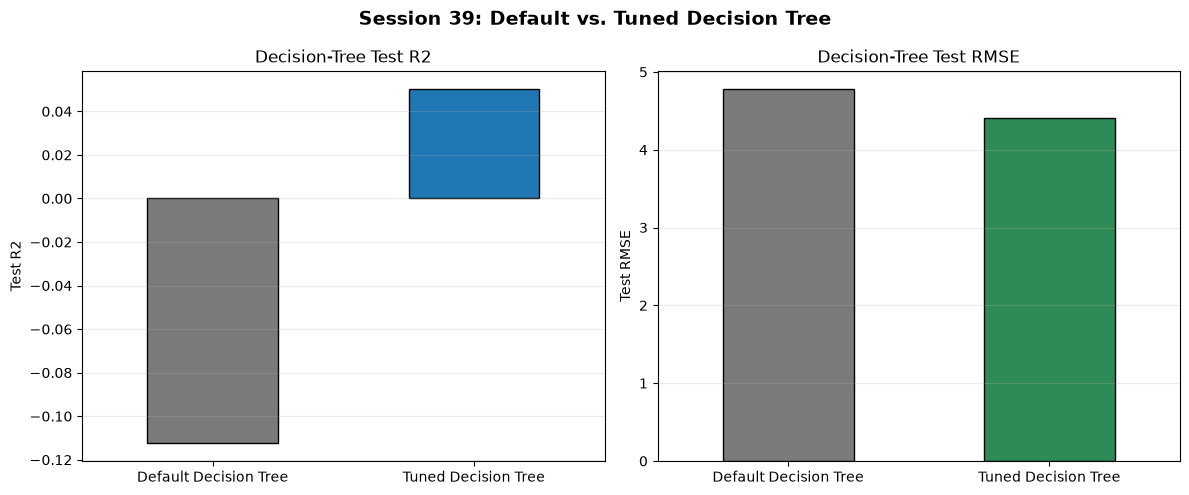

In [9]:
figure_data = comparison_table.set_index("Model")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

figure_data["Test_R2"].plot(
    kind="bar",
    ax=axes[0],
    color=["#7A7A7A", "#1F77B4"],
    edgecolor="black",
)
axes[0].set_title("Decision-Tree Test R2")
axes[0].set_ylabel("Test R2")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.25)

figure_data["Test_RMSE"].plot(
    kind="bar",
    ax=axes[1],
    color=["#7A7A7A", "#2E8B57"],
    edgecolor="black",
)
axes[1].set_title("Decision-Tree Test RMSE")
axes[1].set_ylabel("Test RMSE")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.25)

plt.suptitle(
    "Session 39: Default vs. Tuned Decision Tree",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 6. Interpretation and recommendation

Hyperparameter tuning is worthwhile only when its improvement justifies the added search cost and complexity. A smaller tree can still be preferable when the accuracy difference is modest because it is easier to explain and less likely to overfit.

In [10]:
if test_r2_gain > 0 and rmse_reduction > 0:
    recommendation = (
        "Use the tuned decision tree: it improved test R2 and reduced test RMSE."
    )
elif tuned_results["Tree_Depth"] < default_results["Tree_Depth"]:
    recommendation = (
        "Prefer the tuned tree when interpretability and overfitting control are priorities; "
        "its test improvement is limited, but the model is smaller."
    )
else:
    recommendation = (
        "Retain the default tree for this split because tuning did not produce a clear "
        "generalization improvement."
    )

print("Interpretation:")
print(recommendation)
print()
print("Reflection answer:")
print(
    "A small accuracy gain is not worth the extra complexity when it is within normal "
    "validation variation, does not improve the most important error metric, or makes "
    "the model materially harder to explain and maintain."
)

Interpretation:
Use the tuned decision tree: it improved test R2 and reduced test RMSE.

Reflection answer:
A small accuracy gain is not worth the extra complexity when it is within normal validation variation, does not improve the most important error metric, or makes the model materially harder to explain and maintain.


In [11]:
assert len(grid_results_table) == 12
assert set(best_parameters) == {"max_depth", "min_samples_split"}
assert len(comparison_table) == 2
assert "G1" not in X.columns and "G2" not in X.columns and "G3" not in X.columns

verification = {
    "session": SESSION_NUMBER,
    "dataset_rows": int(len(df)),
    "feature_count": int(X.shape[1]),
    "parameter_combinations": int(number_of_combinations),
    "cross_validation_folds": 5,
    "total_model_fits": int(number_of_fits),
    "best_parameters": best_parameters,
    "best_cross_validated_r2": round(float(grid_search.best_score_), 4),
    "default_test_r2": default_results["Test_R2"],
    "tuned_test_r2": tuned_results["Test_R2"],
    "default_test_rmse": default_results["Test_RMSE"],
    "tuned_test_rmse": tuned_results["Test_RMSE"],
    "early_warning_columns_excluded": True,
    "status": "COMPLETE",
}

print(json.dumps(verification, indent=2, default=str))
print("SESSION 39 NOTEBOOK: COMPLETE")

{
  "session": 39,
  "dataset_rows": 395,
  "feature_count": 30,
  "parameter_combinations": 12,
  "cross_validation_folds": 5,
  "total_model_fits": 60,
  "best_parameters": {
    "max_depth": 3,
    "min_samples_split": 2
  },
  "best_cross_validated_r2": 0.0918,
  "default_test_r2": -0.1124,
  "tuned_test_r2": 0.0505,
  "default_test_rmse": 4.776,
  "tuned_test_rmse": 4.4125,
  "early_warning_columns_excluded": true,
  "status": "COMPLETE"
}
SESSION 39 NOTEBOOK: COMPLETE
